In [2]:
import numpy as np
import torch
import random, os
import torch.nn as nn
import torch.nn.functional as F

In [22]:
words = open("names.txt", "r").read().splitlines()
words[0:5:1] #list

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [23]:
char_list = list(''.join(words)) #list of all characters in the words
char_list_unique = list(set(char_list))#list of unique characters in the words
all_unique_characters_sorted = sorted(char_list_unique) #list of unique characters in the words sorted
print(all_unique_characters_sorted)
print(list(enumerate(all_unique_characters_sorted)))

['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
[(0, 'a'), (1, 'b'), (2, 'c'), (3, 'd'), (4, 'e'), (5, 'f'), (6, 'g'), (7, 'h'), (8, 'i'), (9, 'j'), (10, 'k'), (11, 'l'), (12, 'm'), (13, 'n'), (14, 'o'), (15, 'p'), (16, 'q'), (17, 'r'), (18, 's'), (19, 't'), (20, 'u'), (21, 'v'), (22, 'w'), (23, 'x'), (24, 'y'), (25, 'z')]


In [24]:
stoi = {s: i+1 for i,s in enumerate(all_unique_characters_sorted)} #dictionary of unique characters in the words sorted with their index
stoi['.'] = 0 #adding the '.' character to the dictionary with index 0
print(stoi)

itos = {i: s for s, i in stoi.items()} #dictionary of unique characters in the words sorted with their index reversed
print(itos)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [25]:
vocab_size = n_output = len(char_list_unique) + 1 #number of unique characters in the words sorted + 1 for the '.' character
n_embd = 2 #embedding dimension per character
block_size = 8 #context length 
n_hidden = 128
batch_size = 32
max_steps = int(os.environ.get('STEPS', 200000))

In [26]:
#building the dataset
def build_dataset(ws):
    X = []
    Y = []
    for w in ws:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] #crop the first element and append the new index at the end
        
    row_n_display = 5
    print("X:", X[0:row_n_display], "Y:", Y[0:row_n_display])       
    for xi, yi in zip(X[0:row_n_display], Y[0:row_n_display]):
        print([itos[x] for x in xi], "->", itos[yi])

    X_torch = torch.tensor(X) # (B, T), every row is 1 batch, every column is 1 time step, t-7, t-6, t-5, t-4, t-3, t-2, t-1, t (sequence length = 8)
    Y_torch = torch.tensor(Y)

    print("X:", X_torch.shape,"Y:", Y_torch.shape)

    return X_torch, Y_torch

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])
print('Xtr', tuple(Xtr.shape), f'{Xtr.element_size()*Xtr.nelement()/1e6:.1f} MB')



X: [[0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 25], [0, 0, 0, 0, 0, 0, 25, 21], [0, 0, 0, 0, 0, 25, 21, 8], [0, 0, 0, 0, 25, 21, 8, 5]] Y: [25, 21, 8, 5, 14]
['.', '.', '.', '.', '.', '.', '.', '.'] -> y
['.', '.', '.', '.', '.', '.', '.', 'y'] -> u
['.', '.', '.', '.', '.', '.', 'y', 'u'] -> h
['.', '.', '.', '.', '.', 'y', 'u', 'h'] -> e
['.', '.', '.', '.', 'y', 'u', 'h', 'e'] -> n
X: torch.Size([182625, 8]) Y: torch.Size([182625])
X: [[0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 1], [0, 0, 0, 0, 0, 0, 1, 13], [0, 0, 0, 0, 0, 1, 13, 1], [0, 0, 0, 0, 1, 13, 1, 25]] Y: [1, 13, 1, 25, 0]
['.', '.', '.', '.', '.', '.', '.', '.'] -> a
['.', '.', '.', '.', '.', '.', '.', 'a'] -> m
['.', '.', '.', '.', '.', '.', 'a', 'm'] -> a
['.', '.', '.', '.', '.', 'a', 'm', 'a'] -> y
['.', '.', '.', '.', 'a', 'm', 'a', 'y'] -> .
X: torch.Size([22655, 8]) Y: torch.Size([22655])
X: [[0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 13], [0, 0, 0, 0, 0, 0, 13, 21], [0, 0, 0, 0, 0, 13, 21, 19], [0, 

In [27]:
# Conv1d requires channel first input. (B, C = n_embd, T = context_length) where B is batch size, C is number of channels (to be given by embedding layer), T is sequence length
# current X is now (B, T) where B is batch size, T is sequence length. We need to transform it to (B, C, T).
# We need [C, T] for each batch since we want the convolution to be applied to the sequence length dimension. 
# #The embedding layer will give us [C, T] for each batch. 

# nn.Sequential is a container of nn.Module objects that calls them in order. Everything in it must be a module. x.transpose(1, 2) is a tensor method — PyTorch rejects it
# So the chain must break wherever a non-module operation happens: (B,8) ─ nn.Embedding ─▶ (B,8,n_embd) ─ .transpose(1,2) ─▶ (B,n_embd,8) ─ nn.Conv1d
# This is why nn.Sequential is the exception rather than the norm in real models. 
# It only expresses a straight chain of modules — no branching, no skip connections, no reshapes, no anything-else. 
# *** The moment you need one of those, you write a forward.
# (Your WaveNet-ish model happens to be almost a straight chain, which is why we got this far with Sequential at all. The dilated version earlier could never be one: gated activations multiply two branches together, and skip connections accumulate across layers — neither is expressible as a chain.)

emb = nn.Embedding(num_embeddings=vocab_size, embedding_dim=n_embd) #embedding layer, 27 x Embd_Dim:  (B, T=8) ─ nn.Embedding ─▶ (B, T=8, C=n_embd)
#this need to be(B, C=n_embd, T=8) for Conv1d, so we need to transpose the last two dimensions by manipulating the forward method of the model.
def CreateEmbeddingFromX_BT(x):
    x = emb(x) # (B, T=8) ─ nn.Embedding ─▶ (B, T=8, C=n_embd)
    x = x.transpose(1, 2) # (B, T=8, C=n_embd) ─ .transpose(1, 2) ─▶ (B, C=n_embd, T=8)
    return x

#create WaveNetish model
trunk  = nn.Sequential(
    nn.Conv1d(in_channels=n_embd, out_channels=n_hidden, kernel_size=2, stride=2, padding=0, bias=False), #conv1d layer, fuse 8 -> 4
    nn.BatchNorm1d(num_features=n_hidden), #batch normalization layer
    nn.Tanh(), #tanh activation function
    nn.Conv1d(in_channels=n_hidden, out_channels=n_hidden, kernel_size=2, stride=2, padding=0, bias=False), #conv1d layer, fuse 4 -> 2
    nn.BatchNorm1d(num_features=n_hidden), #batch normalization layer
    nn.Tanh(), #tanh activation function
    nn.Conv1d(in_channels=n_hidden, out_channels=n_hidden, kernel_size=2, stride=2, padding=0, bias=False), #conv1d layer, fuse 2 -> 1
    nn.BatchNorm1d(num_features=n_hidden), #batch normalization layer
    nn.Tanh(), #tanh activation function
    nn.Flatten(1), #flatten layer, (B, H, T=1) -> (B, H)
    output_layer := nn.Linear(in_features=n_hidden, out_features=n_output), #linear layer, (B, H) -> (B, 27)
)
with torch.no_grad():
    output_layer.weight.mul_(0.1) #scale down the weights of the last layer to make the model more stable at the beginning of training

def forward(x):
    return trunk(CreateEmbeddingFromX_BT(x)) #forward method of the model, calling the embedding layer and conv1d layer in order

params = list(emb.parameters()) + list(trunk.parameters())
print(sum(p.nelement() for p in params), 'parameters')

# no need, optimizer doing that: opt.zero_grad(set_to_none=True)
#for p in params:
#    p.requires_grad = True   


70353 parameters


In [28]:
print(Xtr.shape[0])

182625


In [29]:
# ── evaluation ───────────────────────────────────────────────────────────
@torch.no_grad()
def split_loss(X, Y, chunk=8192):
    trunk.eval()
    tot = 0.0
    for i in range(0, X.shape[0], chunk):
        tot += F.cross_entropy(forward(X[i:i+chunk]), Y[i:i+chunk], reduction='sum').item()
    trunk.train()
    return tot / X.shape[0]

In [30]:
# Train
# "for p in parameters: p.grad = None" = opt.zero_grad(set_to_none=True)
# "for p in parameters: p.data += -lr * p.grad" = opt.step()

opt = torch.optim.SGD(params, lr=0.1)
trunk.train() #restores the mode so the training loop continues correctly after the call. Miss it and training silently continues with frozen BatchNorm statistics

for step in range(max_steps):
    for g in opt.param_groups:
        g['lr'] = 0.1 if step < 0.75 * max_steps else 0.01

    #minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,)) #randomly select batch_size number of rows from the training set
    Xb, Yb = Xtr[ix], Ytr[ix] #select the rows from the training set

    Yb_tilda = forward(Xtr[ix])
    loss = F.cross_entropy(Yb_tilda, Yb)
    opt.zero_grad(set_to_none=True)

    loss.backward() #compute gradients
    opt.step() # update parameter (weights) chain

    if step % max(1, max_steps // 10) == 0:
        print(f'{step:7d}/{max_steps}  batch {loss.item():.4f}')

    if step % 100 == 0:
        print(step, loss.item())

print(f'train {split_loss(Xtr,  Ytr ):.4f}')
print(f'dev   {split_loss(Xdev, Ydev):.4f}')
print(f'test  {split_loss(Xte,  Yte ):.4f}')     # touch ONCE, after all tuning



      0/200000  batch 3.2927
0 3.2926876544952393
100 2.5812556743621826
200 2.537064790725708
300 2.9335296154022217
400 2.6277015209198
500 2.885881185531616
600 2.687141180038452
700 2.7446117401123047
800 2.2305383682250977
900 2.6541080474853516
1000 2.7819087505340576
1100 2.2746427059173584
1200 2.4624321460723877
1300 2.443983554840088
1400 2.486844778060913
1500 2.397435188293457
1600 2.62016224861145
1700 2.666959285736084
1800 2.4303336143493652
1900 2.525177001953125
2000 2.7638354301452637
2100 2.6273250579833984
2200 2.3705317974090576
2300 2.670837879180908
2400 2.4255688190460205
2500 2.337155818939209
2600 2.7984533309936523
2700 2.471052646636963
2800 2.2067248821258545
2900 2.4650397300720215
3000 2.5792593955993652
3100 2.0689496994018555
3200 2.25180983543396
3300 2.3148443698883057
3400 2.7438931465148926
3500 1.9165828227996826
3600 2.508983850479126
3700 2.361799955368042
3800 2.3376400470733643
3900 2.1381499767303467
4000 2.2020654678344727
4100 2.742054939270

In [31]:
#Save (run after training)
torch.save({
    'emb':    emb.state_dict(),
    'trunk':  trunk.state_dict(),
    'opt':    opt.state_dict(),          # only needed to RESUME training
    'stoi':   stoi,                      # without this you can't decode samples
    'config': dict(vocab_size=vocab_size, n_embd=n_embd,
                   n_hidden=n_hidden, block_size=block_size),
}, 'wavenet_ckpt.pt')

In [32]:
#Load (run instead of training)
ck = torch.load('wavenet_ckpt.pt', weights_only=True)
cfg = ck['config']

emb   = nn.Embedding(cfg['vocab_size'], cfg['n_embd'])          # rebuild the SAME shapes
trunk  = nn.Sequential(
    nn.Conv1d(in_channels=n_embd, out_channels=n_hidden, kernel_size=2, stride=2, padding=0, bias=False), #conv1d layer, fuse 8 -> 4
    nn.BatchNorm1d(num_features=n_hidden), #batch normalization layer
    nn.Tanh(), #tanh activation function
    nn.Conv1d(in_channels=n_hidden, out_channels=n_hidden, kernel_size=2, stride=2, padding=0, bias=False), #conv1d layer, fuse 4 -> 2
    nn.BatchNorm1d(num_features=n_hidden), #batch normalization layer
    nn.Tanh(), #tanh activation function
    nn.Conv1d(in_channels=n_hidden, out_channels=n_hidden, kernel_size=2, stride=2, padding=0, bias=False), #conv1d layer, fuse 2 -> 1
    nn.BatchNorm1d(num_features=n_hidden), #batch normalization layer
    nn.Tanh(), #tanh activation function
    nn.Flatten(1), #flatten layer, (B, H, T=1) -> (B, H)
    output_layer := nn.Linear(in_features=n_hidden, out_features=n_output), #linear layer, (B, H) -> (B, 27)
)                                     # your existing definition

emb.load_state_dict(ck['emb'])
trunk.load_state_dict(ck['trunk'])
opt.load_state_dict(ck['opt'])                                   # only if resuming
trunk.eval()

Sequential(
  (0): Conv1d(2, 128, kernel_size=(2,), stride=(2,), bias=False)
  (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): Tanh()
  (3): Conv1d(128, 128, kernel_size=(2,), stride=(2,), bias=False)
  (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): Tanh()
  (6): Conv1d(128, 128, kernel_size=(2,), stride=(2,), bias=False)
  (7): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (8): Tanh()
  (9): Flatten(start_dim=1, end_dim=-1)
  (10): Linear(in_features=128, out_features=27, bias=True)
)

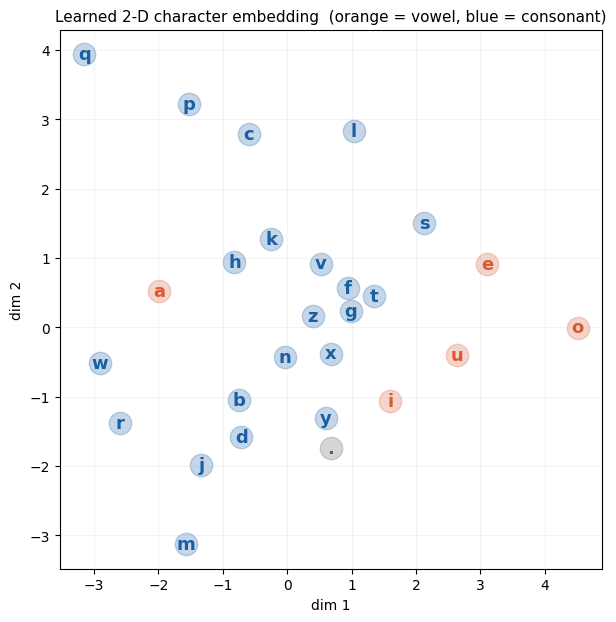

In [42]:
#visualize
import matplotlib.pyplot as plt

W = emb.weight.detach()                 # (vocab_size, 2)
vowels = set('aeiou')

fig, ax = plt.subplots(figsize=(7, 7))
for i in range(vocab_size):
    ch = itos[i]
    c = '#D85A30' if ch in vowels else ('#185FA5' if ch != '.' else '#5F5E5A')
    ax.scatter(W[i, 0], W[i, 1], s=260, color=c, alpha=.25, zorder=1)
    ax.text(W[i, 0], W[i, 1], ch, ha='center', va='center',
            fontsize=13, color=c, fontweight='bold', zorder=2)

ax.set_title('Learned 2-D character embedding  (orange = vowel, blue = consonant)', fontsize=11)
ax.set_xlabel('dim 1'); ax.set_ylabel('dim 2'); ax.grid(alpha=.15)
plt.show()                              # or fig.savefig('embedding_2d.png', dpi=130)

In [ ]:
# ── sample ───────────────────────────────────────────────────────────────
trunk.eval()
g = torch.Generator().manual_seed(2147483647)
for _ in range(20):
    out, ctx = [], [0] * block_size
    while True:
        forward_pass = forward(torch.tensor([ctx]))
        output_dist =  F.softmax(forward_pass, dim=1)
        j = int(torch.multinomial(output_dist, 1, generator=g).item())
        ctx = ctx[1:] + [j]

        if j == 0: break # hit "."

        predicted_character = itos[j]
        out.append(predicted_character)
    print(''.join(out))

junide
jakari
julisay
adrianah
rotolewas
termani
nakaya
brenlan
dedaine
imer
sejaina
lartella
mumery
oltum
maryas
jahoba
jacora
yarion
kaelani
webdoni


In [ ]:
"""
Embedding -> Linear network on a [B, T, C] tensor, drawn as neurons.
Same toy numbers as the chat walkthrough:
    V=5, B=2, T=3, C=3, H=2
    X   = [[1,2,3],[4,1,0]]            token ids, vocab ['.','a','b','c','d']
    emb = (V,C) table, W = (C,H) weights, no bias
Outputs transparent PNG + SVG in a light-background and a dark-background variant.
"""
import numpy as np
import os
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyBboxPatch
from matplotlib.lines import Line2D

# ---------------- data (identical to the chat example) ----------------
VOCAB = ['.', 'a', 'b', 'c', 'd']
emb = np.array([[ 0.1, -0.2,  0.0],
                [ 0.5,  0.1, -0.3],
                [-0.4,  0.2,  0.6],
                [ 0.3, -0.5,  0.2],
                [ 0.0,  0.4, -0.1]])          # (V, C)
X = np.array([[1, 2, 3],
              [4, 1, 0]])                     # (B, T)
W = np.array([[ 1.0, 0.5],
              [-1.0, 0.0],
              [ 0.5, 2.0]])                   # (C, H)
V, C = emb.shape
B, T = X.shape
H = W.shape[1]
E = emb[X]                                    # (B, T, C)
Y = E @ W                                     # (B, T, H)

# ---------------- palette ----------------
POS = "#7F77DD"      # purple: positive weight
NEG = "#D85A30"      # coral: negative weight
ACT = "#1D9E75"      # teal: active one-hot / looked-up row

THEMES = {
    "light": dict(text="#2C2C2A", muted="#5F5E5A", faint="#888780",
                  node_fill="#F1EFE8", node_edge="#5F5E5A", panel="#888780"),
    "dark":  dict(text="#F1EFE8", muted="#D3D1C7", faint="#B4B2A9",
                  node_fill="#2C2C2A", node_edge="#B4B2A9", panel="#B4B2A9"),
}

MONO = "DejaVu Sans Mono"
SANS = "DejaVu Sans"


def fmt(v):
    r = round(float(v), 2)
    return f"{0.0 if r == 0 else r:.2f}"


def draw(theme_name):
    th = THEMES[theme_name]
    fig, ax = plt.subplots(figsize=(16, 10.0))
    fig.patch.set_alpha(0.0)
    ax.set_facecolor("none")
    ax.set_xlim(0, 20)
    ax.set_ylim(-1.0, 11.5)
    ax.set_aspect("equal")
    ax.axis("off")

    # layer heights
    y_tok, y_oh, y_emb, y_out = 0.95, 2.45, 5.65, 8.55
    r_oh, r_emb, r_out = 0.21, 0.36, 0.36
    cxs = [2.45, 6.65, 10.85]                       # centres of t = 0, 1, 2
    dx_oh = np.linspace(-1.45, 1.45, V)
    dx_emb = np.array([-1.05, 0.0, 1.05])
    dx_out = np.array([-0.62, 0.62])

    # ---- batch stack: b=0 panel + visible edge of b=1 behind it ----
    px0, py0, pw, ph = 0.35, 0.25, 12.6, 9.35
    ax.add_patch(FancyBboxPatch((px0, py0), pw, ph, boxstyle="round,pad=0,rounding_size=0.25",
                                fill=False, lw=1.2, ec=th["panel"], zorder=1))
    off = 0.38
    ax.plot([px0 + off, px0 + off, px0 + pw + off, px0 + pw + off, px0 + pw],
            [py0 + ph, py0 + ph + off, py0 + ph + off, py0 + off, py0 + off],
            color=th["panel"], lw=1.0, ls=(0, (4, 3)), zorder=1)
    ax.text(px0 + 0.25, py0 + ph - 0.3, "b = 0", color=th["text"], fontsize=11,
            fontfamily=SANS, fontweight="bold", va="center", zorder=5)
    ax.text(px0 + pw - 0.1, py0 + ph + off / 2 + 0.01,
            "b = 1   tokens 'd' 'a' '.'   (same wiring, same weights)",
            color=th["muted"], fontsize=9, fontfamily=SANS, ha="right", va="center", zorder=5)

    wmax_emb = np.abs(emb).max()
    wmax_W = np.abs(W).max()

    for t, cx in enumerate(cxs):
        tok = X[0, t]

        # ---- edges: one-hot -> embedding (these ARE the emb table) ----
        for v in range(V):
            for c in range(C):
                x1, y1 = cx + dx_oh[v], y_oh + r_oh
                x2, y2 = cx + dx_emb[c], y_emb - r_emb
                if v == tok:
                    w = emb[v, c]
                    col = POS if w > 0 else NEG if w < 0 else th["faint"]
                    lw = 1.0 + 4.0 * abs(w) / wmax_emb
                    ls = "-" if w != 0 else (0, (3, 3))
                    ax.plot([x1, x2], [y1, y2], color=col, lw=lw, ls=ls,
                            solid_capstyle="round", zorder=3)
                else:
                    ax.plot([x1, x2], [y1, y2], color=th["faint"], lw=0.6,
                            alpha=0.22, zorder=2)

        # ---- edges: embedding -> output (W, shared) ----
        for c in range(C):
            for h in range(H):
                w = W[c, h]
                x1, y1 = cx + dx_emb[c], y_emb + r_emb
                x2, y2 = cx + dx_out[h], y_out - r_out
                if w == 0:
                    ax.plot([x1, x2], [y1, y2], color=th["faint"], lw=1.0,
                            ls=(0, (3, 3)), zorder=3)
                else:
                    ax.plot([x1, x2], [y1, y2], color=POS if w > 0 else NEG,
                            lw=1.0 + 3.5 * abs(w) / wmax_W,
                            solid_capstyle="round", zorder=3)

        # ---- nodes: one-hot ----
        for v in range(V):
            active = v == tok
            ax.add_patch(Circle((cx + dx_oh[v], y_oh), r_oh,
                                fc=ACT if active else th["node_fill"],
                                ec=ACT if active else th["node_edge"], lw=1.0, zorder=4))
            ax.text(cx + dx_oh[v], y_oh, "1" if active else "0",
                    color="#FFFFFF" if active else th["muted"],
                    fontsize=9, fontfamily=MONO, ha="center", va="center", zorder=5)
            ax.text(cx + dx_oh[v], y_oh - r_oh - 0.22, f"'{VOCAB[v]}'",
                    color=ACT if active else th["muted"], fontsize=8.5,
                    fontfamily=MONO, ha="center", va="center", zorder=5)

        # ---- nodes: embedding values E[0,t,:] ----
        for c in range(C):
            ax.add_patch(Circle((cx + dx_emb[c], y_emb), r_emb, fc=th["node_fill"],
                                ec=th["node_edge"], lw=1.0, zorder=4))
            ax.text(cx + dx_emb[c], y_emb, fmt(E[0, t, c]), color=th["text"],
                    fontsize=9, fontfamily=MONO, ha="center", va="center", zorder=5)

        # ---- nodes: outputs Y[0,t,:] ----
        for h in range(H):
            ax.add_patch(Circle((cx + dx_out[h], y_out), r_out, fc=th["node_fill"],
                                ec=th["node_edge"], lw=1.0, zorder=4))
            ax.text(cx + dx_out[h], y_out, fmt(Y[0, t, h]), color=th["text"],
                    fontsize=9, fontfamily=MONO, ha="center", va="center", zorder=5)
        ax.text(cx, y_out + r_out + 0.3, f"Y[0,{t},:]", color=th["muted"], fontsize=9,
                fontfamily=MONO, ha="center", va="center", zorder=5)

        # ---- token label under each column ----
        ax.text(cx, y_tok + 0.05, f"t = {t}", color=th["text"], fontsize=11,
                fontfamily=SANS, fontweight="bold", ha="center", va="center", zorder=5)
        ax.text(cx, y_tok - 0.42, f"X[0,{t}] = {tok}  ('{VOCAB[tok]}')", color=th["muted"],
                fontsize=9, fontfamily=MONO, ha="center", va="center", zorder=5)

    # ---- right column: tensor shapes + PyTorch ----
    rx = 13.75

    def label(y, head, sub, head_col=None):
        ax.text(rx, y + 0.2, head, color=head_col or th["text"], fontsize=11.5,
                fontfamily=MONO, fontweight="bold", va="center")
        ax.text(rx, y - 0.25, sub, color=th["muted"], fontsize=9.5, fontfamily=MONO,
                va="center")

    label(y_out, "Y  (B,T,H) = (2,3,2)", "Y = E @ W        # 'btc,ch->bth'")
    label((y_out + y_emb) / 2, "W  (C,H) = (3,2)   learnable",
          "6 weights, reused by all B·T tokens")
    label(y_emb, "E  (B,T,C) = (2,3,3)", "E = emb[X]  ==  one_hot(X) @ emb")
    label((y_emb + y_oh) / 2 - 0.1, "emb  (V,C) = (5,3)   learnable",
          "15 weights, row i = token id i")
    label(y_oh, "one_hot(X)  (B,T,V) = (2,3,5)", "conceptual; emb[X] is a gather")
    label(y_tok, "X  (B,T) = (2,3)", "[[1,2,3], [4,1,0]]   int64 ids")

    # ---- title ----
    ax.text(0.35, 11.2, "Embedding  →  Linear  on a [B, T, C] tensor", color=th["text"],
            fontsize=16, fontfamily=SANS, fontweight="bold", va="center")
    ax.text(0.35, 10.7,
            "V=5  B=2  T=3  C=3  H=2   ·   one token = one column of neurons   ·   "
            "every column shares the same emb and W",
            color=th["muted"], fontsize=10.5, fontfamily=SANS, va="center")

    # ---- legend ----
    ly = -0.55
    items = [
        (Line2D([0], [0], color=POS, lw=3), "positive weight"),
        (Line2D([0], [0], color=NEG, lw=3), "negative weight"),
        (Line2D([0], [0], color=th["faint"], lw=1.2, ls=(0, (3, 3))), "weight = 0"),
        (Line2D([0], [0], marker="o", color="none", markerfacecolor=ACT,
                markeredgecolor=ACT, markersize=10), "active one-hot → selects row of emb"),
    ]
    leg = ax.legend([i[0] for i in items], [i[1] for i in items], loc="center left",
                    bbox_to_anchor=(0.0175, (ly + 1.0) / 12.5), ncol=4, frameon=False,
                    fontsize=10, handlelength=2.2, columnspacing=2.0,
                    labelcolor=th["text"])
    ax.text(19.8, ly, "line width ∝ |weight|", color=th["muted"], fontsize=10,
            fontfamily=SANS, ha="right", va="center")
    output_dir = "/workspace/repos/output"
    os.makedirs(output_dir, exist_ok=True)
    base = f"{output_dir}/embedding_linear_BTC_{theme_name}"
    fig.savefig(base + ".png", dpi=200, transparent=True, bbox_inches="tight", pad_inches=0.15)
    fig.savefig(base + ".png", dpi=200, transparent=True, bbox_inches="tight", pad_inches=0.15)
    fig.savefig(base + ".svg", transparent=True, bbox_inches="tight", pad_inches=0.15)
    plt.close(fig)
    return base


if __name__ == "__main__":
    # sanity check against the chat numbers
    assert np.allclose(Y[0, 2], [0.9, 0.55])
    print("Y[0] =\n", Y[0].round(3))
    for name in THEMES:
        print("saved", draw(name))

Y[0] =
 [[ 0.25 -0.35]
 [-0.3   1.  ]
 [ 0.9   0.55]]


FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/nn_arch/embedding_linear_BTC_light.png'